<a href="https://colab.research.google.com/github/errorinloading/aps_failure_detection_model/blob/main/APS_Report_FIXED_3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# # 📌 APS Failure Detection - README (Google Colab)

# ### 📁 Required Files

# 1.	Open the Google Colab notebook:
# Upload the provided .ipynb file into Google Colab.
# 	2.	Upload the required files:
# In the left-side Files panel, upload:
# 	•	aps_failure_training_set.csv
# 	•	aps_failure_test_set.csv
# 	•	cost_utils.py (if included)
# 	•	requirements_both.txt (optional, for library installation)
# 	3.	Install required libraries (if needed):
# !pip install pandas numpy matplotlib seaborn scikit-learn
# Run the cell sequentially


# 1. Abstract
This project predicts **Air Pressure System (APS)** failures in Scania trucks using sensor data. We handle missing values, class imbalance, and train a **Logistic Regression** model to detect failures early. The evaluation focuses on recall, cost minimization, and precision–recall curves since missing failures (false negatives) are highly costly.

# 2. Introduction
The Air Pressure System (APS) controls braking in heavy-duty Scania trucks. Failures in APS can cause severe safety risks and financial losses. Our aim is to develop a model that predicts potential APS failures from historical sensor data so that preventive maintenance can be scheduled.

# 3. Dataset and Methodology

## 3.1 Dataset Description
- Dataset: Scania APS Failure dataset from UCI ML Repository
- Records: ~60,000 instances with 171 features
- Features: Sensor readings (pressures, flows, temperatures)
- Target: `class` (0 = 'neg' → no failure, 1 = 'pos' → failure)
- Highly imbalanced (~1,000 positive vs. 59,000 negative)
- Missing values represented as `'na'`

## 3.2 Workflow
1. Load and explore dataset
2. Handle missing values (median imputation)
3. Scale features (for Logistic Regression)
4. Train Logistic Regression classifier
5. Evaluate using Accuracy, Precision, Recall, F1-score, ROC-AUC, PR curve
6. Compute APS cost (10×FP + 500×FN)

## 3.3 Data Analysis (Additional from friend's notebook)

The following cells were adapted from the provided friend's notebook and inserted here. They include extra EDA visualizations, Random Forest training and feature importance, and additional plots. Run them after the main data-loading cell.

In [ ]:
# Core scientific stack, visualisation helpers, and modelling utilities
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Standardise plotting aesthetics and suppress noisy warnings
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
# === APS DATASET LOADING & SUMMARY ===

import pandas as pd
import numpy as np

# ✅ Path to your dataset (uploaded to Colab Files)
path = "/content/aps_training_combined_fixed.csv"

# Load dataset
df = pd.read_csv(path,
                 encoding='utf-8-sig',
                 engine='python',
                 on_bad_lines='skip',
                 na_values=['na', 'NA', 'Na', '?', '', 'null', 'None'])

print("✅ APS dataset loaded successfully!")
print("Shape:", df.shape)

# Convert class labels to numeric (1 = failure / pos, 0 = normal / neg)
df['class'] = df['class'].astype(str).str.strip().str.lower()
df['class'] = df['class'].map({'pos': 1, 'neg': 0})

# Quick structural summary
basic_summary = pd.Series({
    "Rows": df.shape[0],
    "Columns": df.shape[1],
    "Missing values": int(df.isna().sum().sum()),
    "Duplicate rows": int(df.duplicated().sum()),
    "Failure count (pos)": int(df['class'].sum()),
    "Normal count (neg)": int((df['class'] == 0).sum())
})

print("\nDataset Overview:")
display(basic_summary.to_frame(name="value"))

print("\nTarget Distribution:")
display(df['class'].value_counts(dropna=False).rename_axis('class').to_frame('count'))

# Preview first few sensor columns and target
display(df.head())

✅ APS dataset loaded successfully!
Shape: (2058, 171)

Dataset Overview:


,value
Rows,2058
Columns,171
Missing values,28971
Duplicate rows,0
Failure count (pos),40
Normal count (neg),2018



Target Distribution:


,count
class,
0,2018
1,40


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,...,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,0,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,0.0,37250.0,1432864.0,3664156.0,1007684.0,25896.0,0.0,2551696.0,0.0,0.0,0.0,0.0,0.0,4933296.0,3655166.0,...,0.0,0.0,202710.0,37928.0,14745580.0,1876644.0,0.0,0.0,0.0,0.0,2801180.0,2445.80,2712.0,965866.0,1706908.0,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,0,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,18254.0,653294.0,1720800.0,516724.0,31642.0,0.0,1393352.0,0.0,68.0,0.0,0.0,0.0,2560898.0,2127150.0,...,0.0,0.0,103330.0,16254.0,4510080.0,868538.0,0.0,0.0,0.0,0.0,3477820.0,2211.76,2334.0,664504.0,824154.0,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,0,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1648.0,370592.0,1883374.0,292936.0,12016.0,0.0,1234132.0,0.0,0.0,0.0,0.0,0.0,2371990.0,2173634.0,...,0.0,0.0,65772.0,10534.0,300240.0,48028.0,0.0,0.0,0.0,0.0,1040120.0,1018.64,1020.0,262032.0,453378.0,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,0,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,318.0,2212.0,3232.0,1872.0,0.0,0.0,0.0,2668.0,0.0,0.0,0.0,642.0,3894.0,10184.0,7554.0,...,2014.0,370.0,48.0,18.0,15740.0,1822.0,20174.0,44.0,0.0,0.0,0.0,1.08,54.0,5670.0,1566.0,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,0,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,0.0,43752.0,1966618.0,1800340.0,131646.0,4588.0,0.0,1974038.0,0.0,226.0,0.0,0.0,0.0,3230626.0,2618878.0,...,0.0,0.0,149474.0,35154.0,457040.0,80482.0,98334.0,27588.0,0.0,0.0,21173050.0,1116.06,1176.0,404740.0,904230.0,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0


In [ ]:
# Define the target column for APS dataset
target_col = "class"

Top features by missing ratio:


,missing_ratio
br_000,82.85%
bq_000,81.83%
bp_000,80.27%
bo_000,77.75%
ab_000,77.45%
cr_000,77.45%
bn_000,73.03%
bm_000,64.72%
bl_000,44.36%
bk_000,37.22%


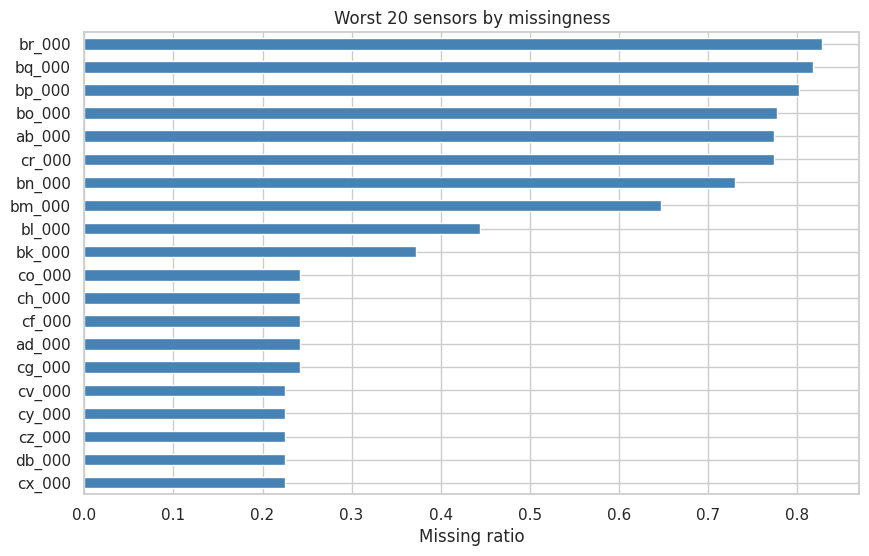

Dropped columns with >50% missing: 8
Remaining features: 162 (excluding target)
Highest post-imputation missing ratio: 0.00%


In [ ]:
# Work on a copy to preserve the raw ingestion output
df_clean = df.copy()
feature_columns = [col for col in df_clean.columns if col not in {"timestamp", target_col}]

# Quantify missingness across sensors and focus on the worst offenders
missing_ratio = df_clean[feature_columns].isna().mean().sort_values(ascending=False)
missing_summary = missing_ratio.head(20).to_frame(name="missing_ratio")

print("Top features by missing ratio:")
display(missing_summary.style.format({"missing_ratio": "{:.2%}"}))

if not missing_summary.empty:
    ax = missing_summary.sort_values("missing_ratio").plot(kind="barh", legend=False, color="steelblue")
    ax.set_xlabel("Missing ratio")
    ax.set_title("Worst 20 sensors by missingness")
    plt.show()

# Remove sensors that are mostly empty, then fill the remainder with robust medians
high_missing_cols = missing_ratio[missing_ratio > 0.5].index.tolist()
if high_missing_cols:
    df_clean = df_clean.drop(columns=high_missing_cols)

numeric_features = [col for col in df_clean.select_dtypes(include=[np.number]).columns if col != target_col]

median_values = df_clean[numeric_features].median()
df_clean[numeric_features] = df_clean[numeric_features].fillna(median_values)

if "timestamp" in df_clean.columns and df_clean["timestamp"].isna().any():
    df_clean["timestamp"] = df_clean["timestamp"].fillna(method="ffill").fillna(method="bfill")

post_missing_ratio = df_clean.isna().mean().max()

print(
    f"Dropped columns with >50% missing: {len(high_missing_cols)}\n"
    f"Remaining features: {len(df_clean.columns) - 1} (excluding target)\n"
    f"Highest post-imputation missing ratio: {post_missing_ratio:.2%}"
)

Distribution statistics for high-variance sensors:


,mean,std,skew,kurtosis
ac_000,3.478708e+08,7.877164e+08,1.822120,1.320122
dq_000,4.050176e+06,7.553113e+07,32.224665,1117.893927
eb_000,7.509367e+06,2.702466e+07,13.681084,296.238631
bb_000,4.504540e+06,1.060851e+07,5.998484,44.586295
bu_000,4.442804e+06,1.044695e+07,6.071364,45.999853
bv_000,4.442806e+06,1.044695e+07,6.071364,45.999854


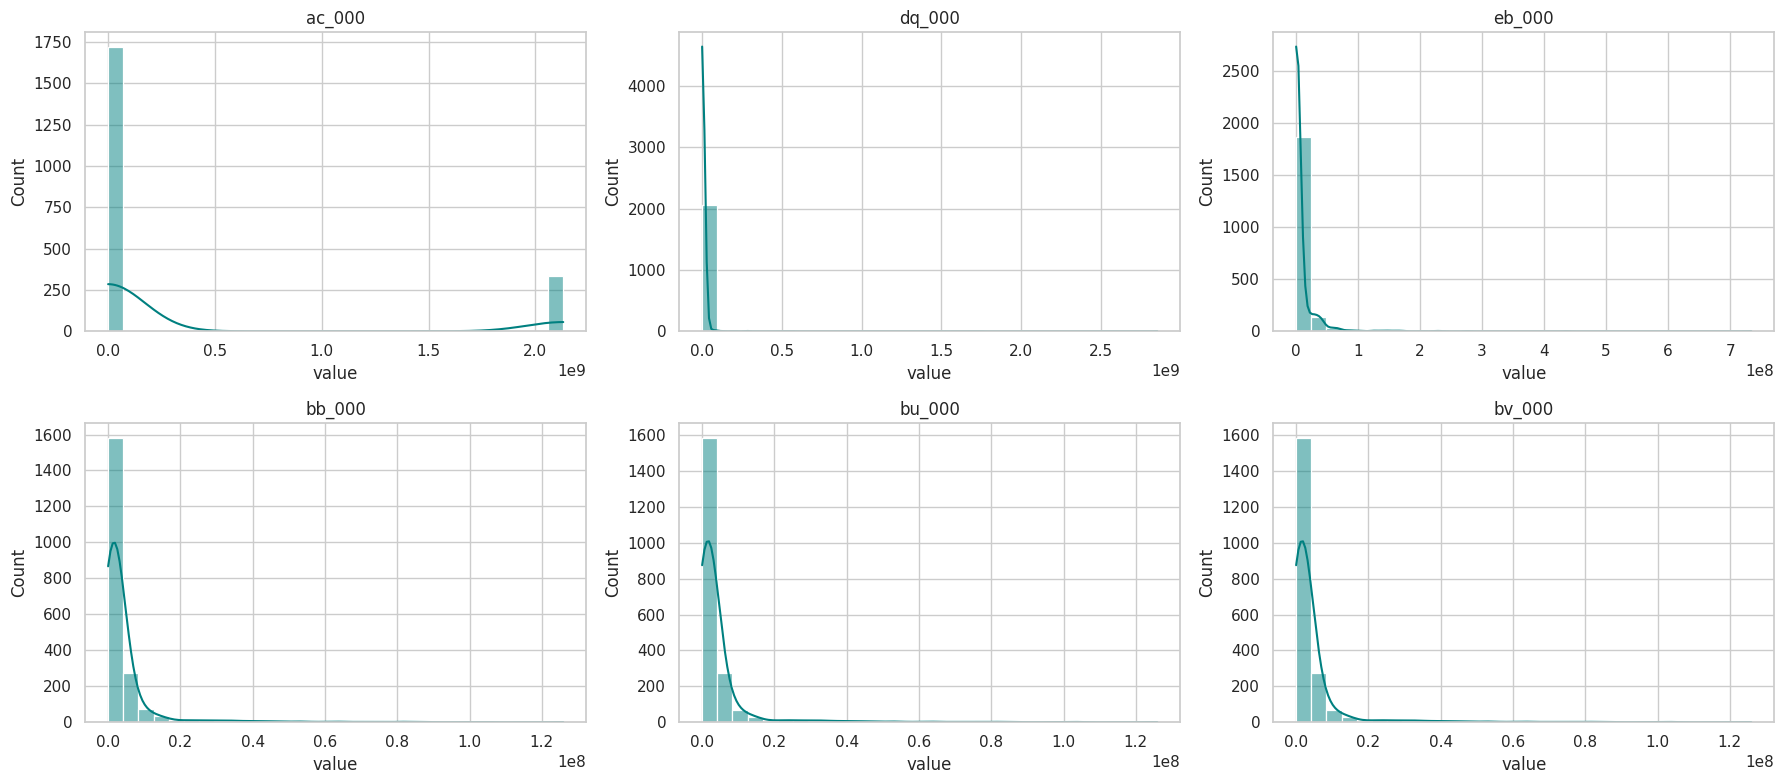

In [ ]:
# Focus on the most variable sensors — they often drive downstream models
variance_rank = df_clean[numeric_features].var().sort_values(ascending=False)
representative_features = variance_rank.head(6).index.tolist()

# Summarise key distribution moments for these sensors
stats_table = pd.DataFrame(
    {
        "mean": df_clean[representative_features].mean(),
        "std": df_clean[representative_features].std(),
        "skew": df_clean[representative_features].apply(stats.skew),
        "kurtosis": df_clean[representative_features].apply(stats.kurtosis),
    }
)

print("Distribution statistics for high-variance sensors:")
display(stats_table)

# Visual review to spot skew, multimodality, or truncation issues
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, feature in zip(axes.flatten(), representative_features):
    sns.histplot(df_clean[feature], kde=True, ax=ax, color="teal", bins=30)
    ax.set_title(feature)
    ax.set_xlabel("value")
plt.tight_layout()
plt.show()

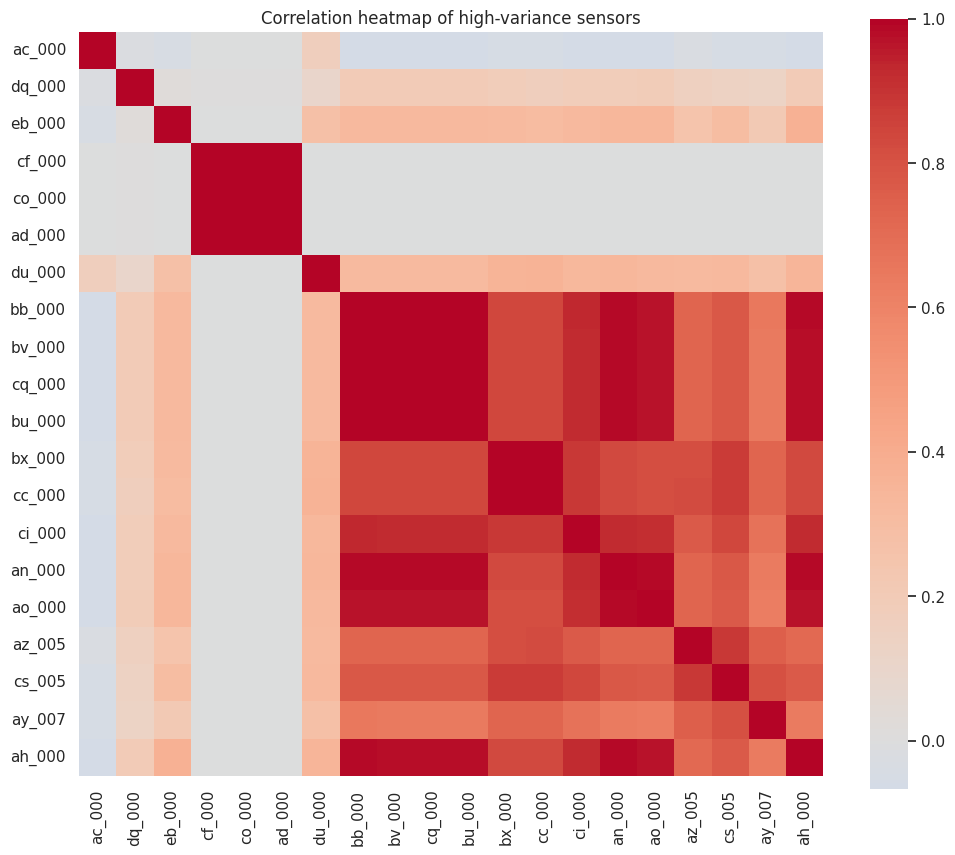

Approximate VIF scores (higher implies more multicollinearity):


,VIF
cq_000,4.509491e+11
bv_000,3.963445e+11
bu_000,5.506300e+10
cf_000,2.840519e+08
co_000,1.757068e+08
ad_000,1.521310e+08
bb_000,1.732219e+02
bx_000,1.631749e+02
cc_000,1.625997e+02
an_000,1.102063e+02


In [ ]:
# Use the high-variance sensors to probe redundancy patterns
corr_features = variance_rank.head(20).index.tolist()
corr_matrix = df_clean[corr_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True)
plt.title("Correlation heatmap of high-variance sensors")
plt.show()

# Approximate VIF from the correlation matrix to quantify multicollinearity risk
scaler_for_vif = StandardScaler()
scaled_subset = scaler_for_vif.fit_transform(df_clean[corr_features])
correlation_subset = np.corrcoef(scaled_subset, rowvar=False)
inv_corr = np.linalg.pinv(correlation_subset)
vif_scores = pd.Series(np.diag(inv_corr), index=corr_features)

print("Approximate VIF scores (higher implies more multicollinearity):")
display(vif_scores.sort_values(ascending=False).to_frame(name="VIF"))

Original dimensionality: 162 features
Reduced dimensionality (90% variance target): 61 components
PCA component requirements for key variance thresholds:


,variance_target,components
0,80%,40
1,90%,61
2,95%,79


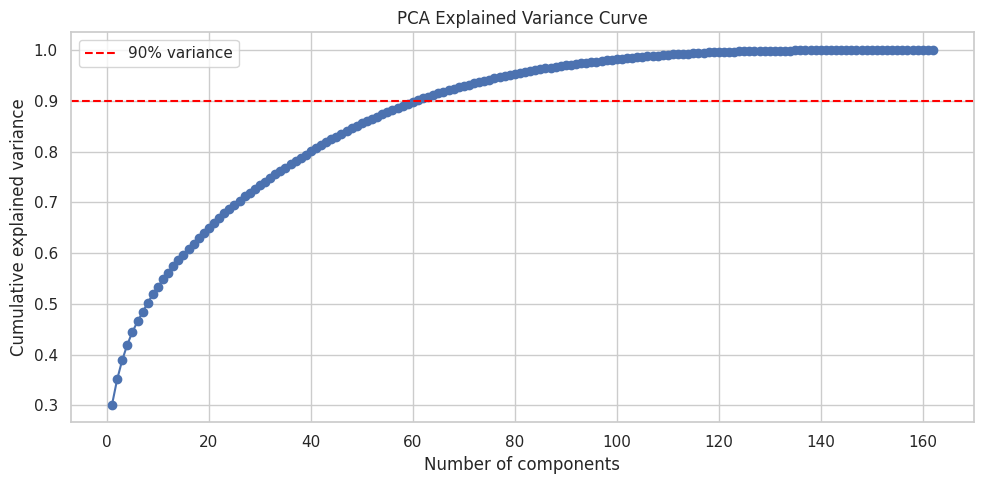

In [ ]:
# Prepare the modelling matrix (exclude timestamp to avoid leakage)
model_features = [col for col in df_clean.columns if col not in {"timestamp", target_col}]
X_full = df_clean[model_features].values
y_full = df_clean[target_col].replace({-1: 0, 1: 1}).astype(int)

# Benchmark PCA on the fully scaled feature set to understand dimensionality needs
scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_full)

pca_full = PCA()
pca_full.fit(X_full_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

variance_targets = [0.80, 0.90, 0.95]
components_needed = {
    f"var_{int(target * 100)}": int(np.argmax(cumulative_variance >= target) + 1)
    for target in variance_targets
}
optimal_components = components_needed.get("var_90", pca_full.n_components_)

print(
    f"Original dimensionality: {X_full.shape[1]} features\n"
    f"Reduced dimensionality (90% variance target): {optimal_components} components"
)

variance_table = pd.DataFrame(
    {
        "variance_target": [f"{int(target * 100)}%" for target in variance_targets],
        "components": [components_needed[f"var_{int(target * 100)}"] for target in variance_targets],
    }
)

print("PCA component requirements for key variance thresholds:")
display(variance_table)

# Visualise cumulative variance to confirm the component choice
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(0.9, color="red", linestyle="--", label="90% variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance Curve")
plt.legend()
plt.tight_layout()
plt.show()

Fitting modelling pipeline (scaler -> PCA -> LogisticRegression)...
Pipeline fitted. Components: 50

Validation report (threshold=0.5):
              precision    recall  f1-score   support

         neg       1.00      0.97      0.99     11800
         pos       0.37      0.94      0.54       200

    accuracy                           0.97     12000
   macro avg       0.69      0.95      0.76     12000
weighted avg       0.99      0.97      0.98     12000

ROC-AUC: 0.978717372881356
Confusion matrix: [11488   312    13   187]

Top 10 sensors ranked by absolute influence (approx):


,approx_weight
ch_000,-15.745491
ar_000,0.009523
ef_000,0.009410
da_000,-0.006746
eg_000,-0.006561
db_000,-0.006155
dz_000,0.003277
ea_000,0.000191
az_009,-0.000149
cm_000,0.000116


/tmp/ipython-input-3799863021.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="crest")


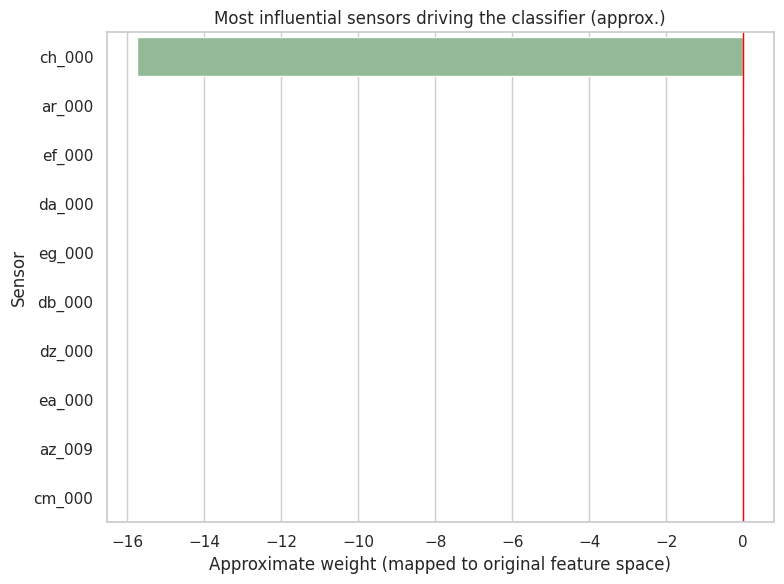

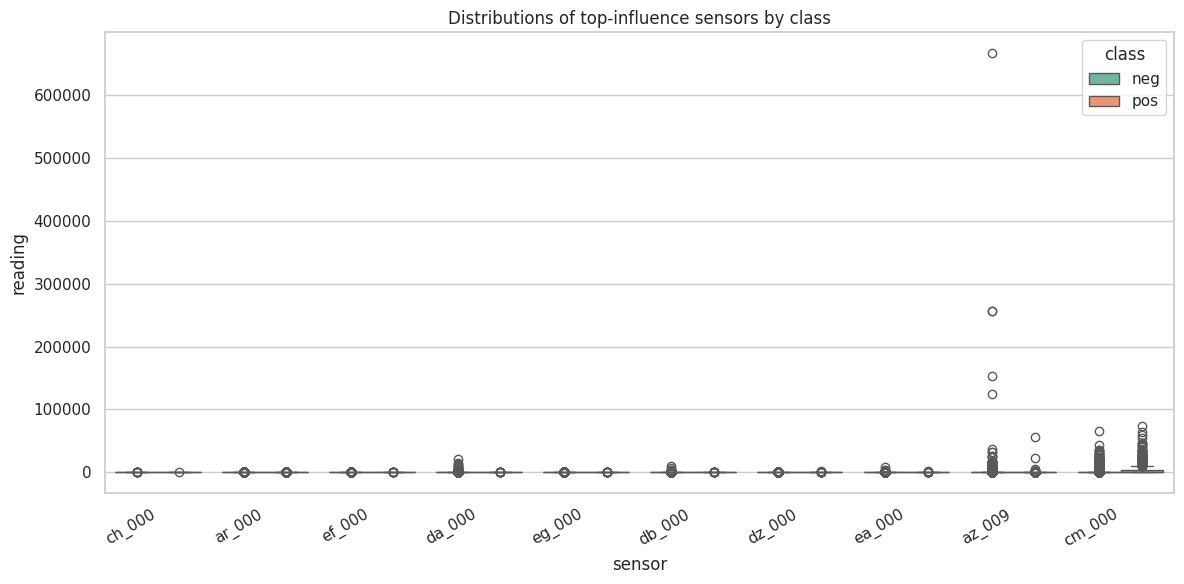

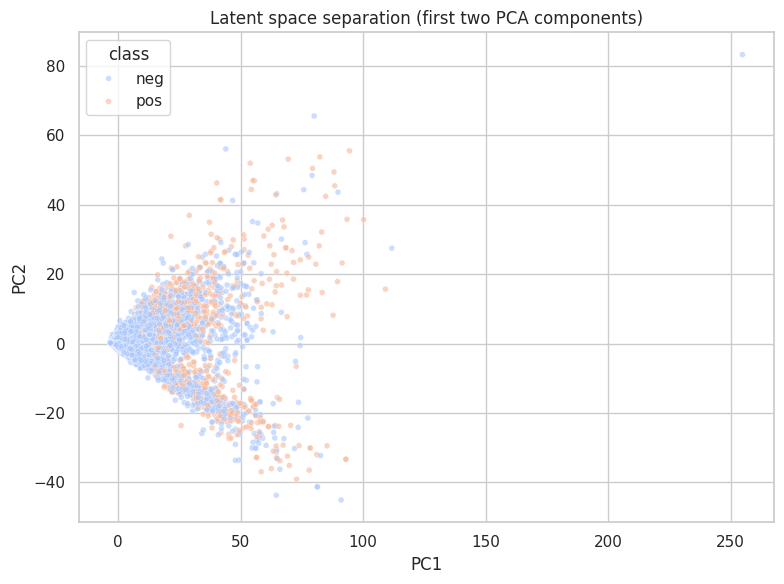

Saved pipeline to model_pipeline_aps_lr_pca.joblib


In [ ]:
# -------------------------
# Fit modelling pipeline and run feature visualisations
# Paste & run this after df_clean exists
# -------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# CONFIG: adjust if you want fewer PCA components
MAX_PCA_COMPONENTS = 50        # number of PCA components to keep (cap for speed)
CLASS_WEIGHT_POS = 50          # keep same weighting you used earlier

# Ensure target_col is defined (should be 'class' for APS)
if 'target_col' not in globals():
    target_col = 'class'  # fallback

# Define list of model features (numeric features excluding timestamp & target)
model_features = [
    c for c in df_clean.columns
    if c not in {'timestamp', target_col} and pd.api.types.is_numeric_dtype(df_clean[c])
]
n_features = len(model_features)
if n_features == 0:
    raise RuntimeError("No numeric features found in df_clean. Check preprocessing step.")

n_components = min(MAX_PCA_COMPONENTS, n_features)

# Prepare X, y
X = df_clean[model_features].copy()
y = df_clean[target_col].copy()

# If labels are pos/neg or 1/0, ensure y is numeric 0/1
if y.dtype == object:
    y = y.astype(str).str.strip().str.lower().map({'pos':1,'neg':0,'1':1,'0':0}).fillna(0).astype(int)
else:
    y = y.fillna(0).astype(int)

# Simple train/test split so the model is not shown on full data (you may train on full data if desired)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Build pipeline
scaler = StandardScaler(with_mean=False)   # with_mean=False to be safe with sparse or large data; matches earlier usage
pca = PCA(n_components=n_components, random_state=42)
logreg = LogisticRegression(max_iter=2000, class_weight={0:1, 1:CLASS_WEIGHT_POS}, solver='liblinear')

model_pipeline = Pipeline([
    ('scaler', scaler),
    ('pca', pca),
    ('logreg', logreg)
])

# Fit pipeline
print("Fitting modelling pipeline (scaler -> PCA -> LogisticRegression)...")
model_pipeline.fit(X_train.fillna(X_train.median()), y_train)
print("Pipeline fitted. Components:", model_pipeline.named_steps['pca'].n_components_)

# (Optional) Evaluate quickly on validation set
proba_valid = model_pipeline.predict_proba(X_valid.fillna(X_train.median()))[:,1]
yhat_valid = (proba_valid >= 0.5).astype(int)
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
print("\nValidation report (threshold=0.5):")
print(classification_report(y_valid, yhat_valid, target_names=['neg','pos']))
print("ROC-AUC:", roc_auc_score(y_valid, proba_valid))
print("Confusion matrix:", confusion_matrix(y_valid, yhat_valid).ravel())

# -------------------------
# Feature visualisation (map LR weights back to original sensors)
# -------------------------
scaler_model = model_pipeline.named_steps['scaler']
pca_model = model_pipeline.named_steps['pca']
logreg_model = model_pipeline.named_steps['logreg']

# logistic coef shape: (1, n_components) for binary case using liblinear
coef_components = logreg_model.coef_.reshape(1, -1)   # shape (1, k)
proj_weights = coef_components @ pca_model.components_   # (1,k) x (k, n_features) -> (1, n_features)

# undo scaler scaling (StandardScaler.scale_ exists)
if hasattr(scaler_model, "scale_"):
    sensor_weights = (proj_weights / scaler_model.scale_).flatten()
else:
    sensor_weights = proj_weights.flatten()

feature_weights = pd.Series(sensor_weights, index=model_features)

# Top absolute influence sensors
top_k = 10
top_features = feature_weights.reindex(feature_weights.abs().sort_values(ascending=False).head(top_k).index)

print(f"\nTop {top_k} sensors ranked by absolute influence (approx):")
display(top_features.to_frame(name="approx_weight"))

# Barplot of top features
plt.figure(figsize=(8,6))
sns.barplot(x=top_features.values, y=top_features.index, palette="crest")
plt.axvline(0, color="red", linewidth=1)
plt.xlabel("Approximate weight (mapped to original feature space)")
plt.ylabel("Sensor")
plt.title("Most influential sensors driving the classifier (approx.)")
plt.tight_layout()
plt.show()

# -------------------------
# Compare distributions of the most influential sensors across classes
# -------------------------
# Map class values to readable labels
class_map = {0: "neg", 1: "pos"}
sensor_view = df_clean[top_features.index.tolist() + [target_col]].copy()
sensor_view[target_col] = sensor_view[target_col].map(class_map).fillna("Unknown")

melted = sensor_view.melt(id_vars=target_col, var_name="sensor", value_name="reading")
plt.figure(figsize=(12, 6))
sns.boxplot(data=melted, x="sensor", y="reading", hue=target_col, palette="Set2")
plt.title("Distributions of top-influence sensors by class")
plt.xlabel("sensor")
plt.ylabel("reading")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# -------------------------
# Visualise separation in the first two PCA components
# -------------------------
# Transform whole cleaned dataset into PCA space
X_full_scaled = scaler_model.transform(X.fillna(X_train.median()))
pca_coords = pca_model.transform(X_full_scaled)
pca_df = pd.DataFrame(pca_coords[:, :2], columns=["PC1", "PC2"])
pca_df["class"] = df_clean[target_col].map(class_map).fillna("Unknown").values

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="class", palette="coolwarm", alpha=0.6, s=18)
plt.title("Latent space separation (first two PCA components)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()

# Save pipeline object for later use if needed
import joblib
joblib.dump(model_pipeline, "model_pipeline_aps_lr_pca.joblib")
print("Saved pipeline to model_pipeline_aps_lr_pca.joblib")

In [ ]:
# --- Compatibility cell (run this after Code 1) ---

if "model_pipeline" not in globals():
    raise RuntimeError("Model pipeline not found. Run the training cell first.")

logreg = model_pipeline.named_steps["logreg"]
pca_model = model_pipeline.named_steps["pca"]
scaler_model = model_pipeline.named_steps["scaler"]

# create class mapping name if later cells expect it
class_mapping = {0: "neg", 1: "pos"}

print("Compatibility variables prepared successfully.")

Compatibility variables prepared successfully.


In [ ]:
# if "model_pipeline" not in globals():
#     raise RuntimeError("Run the modelling pipeline cell before generating feature visualisations.")

# logreg = model_pipeline.named_steps["logreg"]
# pca_model = model_pipeline.named_steps["pca"]
# scaler_model = model_pipeline.named_steps["scaler"]

# # Project logistic regression weights back into the original sensor space
# component_weights = logreg.coef_.reshape(1, -1)
# projected_weights = component_weights @ pca_model.components_
# sensor_weights = (projected_weights / scaler_model.scale_).flatten()
# feature_weights = pd.Series(sensor_weights, index=model_features)

# # Highlight the sensors with the strongest absolute influence
# top_k = 10
# top_features = feature_weights.reindex(feature_weights.abs().sort_values(ascending=False).head(top_k).index)

# print(f"Top {top_k} sensors ranked by absolute influence:")
# display(top_features.to_frame(name="approx_weight"))

# plt.figure(figsize=(10, 6))
# sns.barplot(x=top_features.values, y=top_features.index, palette="crest")
# plt.axvline(0, color="red", linewidth=1)
# plt.xlabel("Approximate weight (mapped to original feature space)")
# plt.ylabel("sensor")
# plt.title("Most influential sensors driving the classifier")
# plt.tight_layout()
# plt.show()

# # Compare distributions of the most influential sensors across classes
# class_mapping = {-1: "Pass", 1: "Fail"}
# sensor_view = df_clean[top_features.index.tolist() + [target_col]].copy()
# sensor_view[target_col] = sensor_view[target_col].map(class_mapping).fillna("Unknown")

# melted = sensor_view.melt(id_vars=target_col, var_name="sensor", value_name="reading")
# plt.figure(figsize=(12, 6))
# sns.boxplot(data=melted, x="sensor", y="reading", hue=target_col, palette="Set2")
# plt.title("Distributions of top-influence sensors by class")
# plt.xlabel("sensor")
# plt.ylabel("reading")
# plt.xticks(rotation=30, ha="right")
# plt.tight_layout()
# plt.show()

# # Visualise separation in the first two principal components
# scaled_features = scaler_model.transform(df_clean[model_features])
# pca_coordinates = pca_model.transform(scaled_features)
# pca_df = pd.DataFrame(pca_coordinates[:, :2], columns=["PC1", "PC2"])
# pca_df["class"] = sensor_view[target_col]

# plt.figure(figsize=(8, 6))
# sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="class", palette="coolwarm", alpha=0.6)
# plt.title("Latent space separation (first two PCA components)")
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.tight_layout()
# plt.show()

In [ ]:
# Robust test-set loader + predictor (run after you have model_pipeline and model_features)
import pandas as pd, numpy as np, os
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

TEST_PATH = "/content/aps_failure_test_set.csv"   # update if different

def find_header_line_index(path, max_probe_lines=400):
    # look for a line that looks like a CSV header (many commas) or contains 'class' column name
    with open(path, "r", encoding="utf-8-sig", errors="ignore") as f:
        for i, line in enumerate(f):
            low = line.lower()
            if low.count(",") >= 5 or ("class" in low and low.count(",") >= 2):
                return i
            if i >= max_probe_lines:
                break
    return 0

# 1) Try quick read with na_values parameter to handle 'na' strings
try:
    test_df = pd.read_csv(TEST_PATH, encoding="utf-8-sig", engine="python",
                         on_bad_lines="skip", na_values=['na', 'NA', 'NaN', 'null', 'None', ''])
except Exception as e:
    print("Initial read failed:", e)
    test_df = pd.read_csv(TEST_PATH, encoding="utf-8-sig", engine="python",
                         on_bad_lines="skip", header=None, na_values=['na', 'NA', 'NaN', 'null', 'None', ''])

print("Initial test shape:", test_df.shape)

# If it looks wrong (1 column or just a short file), attempt to find header and re-read
if test_df.shape[1] == 1:
    hdr = find_header_line_index(TEST_PATH)
    if hdr > 0:
        print(f"Detected probable header at line {hdr}; re-reading with skiprows={hdr}")
        test_df = pd.read_csv(TEST_PATH, skiprows=hdr, header=0, encoding="utf-8-sig",
                             engine="python", on_bad_lines="skip", na_values=['na', 'NA', 'NaN', 'null', 'None', ''])
    else:
        print("No clear header detected — attempting a fallback read")
        test_df = pd.read_csv(TEST_PATH, encoding="utf-8-sig", engine="python",
                             on_bad_lines="skip", na_values=['na', 'NA', 'NaN', 'null', 'None', ''])

print("After robust read, test shape:", test_df.shape)
print("Test columns preview:", list(test_df.columns)[:10])

# 2) Normalise class label if present
if "class" in test_df.columns:
    test_df["class"] = test_df["class"].astype(str).str.strip().str.lower().map({"pos":1,"neg":0}).astype("Int64")

# 3) Ensure model_features exists
if 'model_features' not in globals():
    raise RuntimeError("model_features not found — run the model training / preprocessing cells first.")

# 4) Align columns to training features
missing_cols = [c for c in model_features if c not in test_df.columns]
extra_cols = [c for c in test_df.columns if c not in model_features and c != "class"]

print(f"Missing columns in test set: {len(missing_cols)}; Extra columns: {len(extra_cols)}")

# Add missing columns as NaN (do it in one shot using reindex)
test_df_aligned = test_df.reindex(columns=list(model_features) + (["class"] if "class" in test_df.columns else []))

# 5) Quick sanity check: warn if many columns are missing
if len(missing_cols) > 0:
    print("WARNING: The test set was missing these columns (showing up to 20):")
    print(missing_cols[:20])

# 6) Prepare X_test and fill missing values with medians from training (if possible)
X_test = test_df_aligned[model_features].copy()

# Convert all columns to numeric, coercing errors to NaN
for col in X_test.columns:
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# If you computed median from training earlier, use it; otherwise compute from training df_clean
if 'median_values' in globals():
    med = median_values  # from earlier df_clean step (pandas Series)
else:
    # try to compute medians from df_clean if available
    if 'df_clean' in globals():
        med = df_clean[model_features].median()
    else:
        med = X_test.median()  # fallback to test medians (not ideal)

# Fill missing numeric values
X_test = X_test.fillna(med)

# Define cost constants if not already defined
if 'COST_FP' not in globals():
    COST_FP = 10
    COST_FN = 500

# 7) Run predictions
proba = model_pipeline.predict_proba(X_test)[:,1]
pred = (proba >= 0.5).astype(int)
labels = np.where(pred==1, "pos", "neg")

# Attach predictions to test_df_aligned
out = test_df_aligned.copy()
out['predicted_prob_pos'] = proba
out['predicted_class'] = labels

# 8) If true labels exist, evaluate
if 'class' in out.columns and out['class'].notna().any():
    y_true = out['class'].astype(int).values
    y_pred = (out['predicted_class'] == "pos").astype(int)
    print("\n=== Test set evaluation ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=['neg','pos']))
    print("ROC-AUC:", roc_auc_score(y_true, proba))
    cm = confusion_matrix(y_true, y_pred).ravel()
    print("Confusion matrix [tn, fp, fn, tp]:", cm.tolist())
    # APS cost if labels available
    fp = int(cm[1]); fn = int(cm[2])
    total_cost = COST_FP * fp + COST_FN * fn
    print("APS total cost (FP=10, FN=500):", total_cost)
else:
    print("\nNo true labels found in test set — saved predictions only.")

# 9) Save CSV
out_csv = "aps_test_predictions.csv"
out.to_csv(out_csv, index=False)
print(f"\nSaved predictions to: {out_csv}")


Initial test shape: (10, 1)
Detected probable header at line 20; re-reading with skiprows=20
After robust read, test shape: (16000, 171)
Test columns preview: ['class', 'aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002']
Missing columns in test set: 0; Extra columns: 8

=== Test set evaluation ===
Accuracy: 0.9743125
              precision    recall  f1-score   support

         neg       1.00      0.98      0.99     15625
         pos       0.48      0.92      0.63       375

    accuracy                           0.97     16000
   macro avg       0.74      0.95      0.81     16000
weighted avg       0.99      0.97      0.98     16000

ROC-AUC: 0.9856969386666666
Confusion matrix [tn, fp, fn, tp]: [15244, 381, 30, 345]
APS total cost (FP=10, FN=500): 18810

Saved predictions to: aps_test_predictions.csv


In [ ]:
# ---- Clean numeric columns in aligned test set, fill missing, predict ----
import numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# test_df_aligned should exist from the robust loader cell
print("Pre-predict test shape:", test_df_aligned.shape)

# 1) Ensure all model feature columns are present
missing_cols = [c for c in model_features if c not in test_df_aligned.columns]
if missing_cols:
    print(f"ERROR: Still missing {len(missing_cols)} columns. Showing up to 10: {missing_cols[:10]}")
else:
    print("All model feature columns present.")

# 2) Coerce feature columns to numeric (coerce errors -> NaN)
non_numeric_counts = {}
for c in model_features:
    # count non-numeric entries before coercion
    col = test_df_aligned[c]
    # treat strings that look like 'na' or '?' as NaN explicitly
    if col.dtype == object:
        # quick replace common tokens
        col = col.replace({"na": np.nan, "NA": np.nan, "Na": np.nan, "?": np.nan, "null": np.nan, "None": np.nan})
        test_df_aligned[c] = col
    # now coerce to numeric
    before_non_numeric = int(test_df_aligned[c].apply(lambda x: isinstance(x, str)).sum())
    test_df_aligned[c] = pd.to_numeric(test_df_aligned[c], errors='coerce')
    after_non_numeric = int(test_df_aligned[c].isna().sum())
    non_numeric_counts[c] = after_non_numeric

# 3) Summary of coercion
total_non_numeric = sum(1 for v in non_numeric_counts.values() if v>0)
print(f"Columns with coerced non-numeric -> NaN: {total_non_numeric} / {len(model_features)}")
if total_non_numeric:
    # show top 10 worst
    top_bad = sorted(non_numeric_counts.items(), key=lambda kv: kv[1], reverse=True)[:10]
    print("Top columns by coerced NaNs (col, coerced_count):")
    for col, cnt in top_bad:
        print(f"  {col}: {cnt}")

# 4) Fill NaNs using training medians if available
if 'median_values' in globals() and isinstance(median_values, pd.Series):
    med = median_values.reindex(model_features)
    print("Using median_values from training preprocessing.")
elif 'df_clean' in globals():
    med = df_clean[model_features].median()
    print("Computed medians from df_clean.")
else:
    med = test_df_aligned[model_features].median()
    print("Fallback: using medians computed from the test data (less ideal).")

# 5) Report pre-fill missing ratio
pre_fill_missing_pct = (test_df_aligned[model_features].isna().mean().max()) * 100
print(f"Max missing ratio before fill: {pre_fill_missing_pct:.2f}%")

# Fill in one shot (avoids DataFrame fragmentation)
test_X = test_df_aligned[model_features].fillna(med)

post_fill_missing_pct = (test_X.isna().mean().max()) * 100
print(f"Max missing ratio after fill: {post_fill_missing_pct:.2f}%")

# 6) Convert to numpy and run predictions
try:
    proba = model_pipeline.predict_proba(test_X)[:,1]
except Exception as e:
    # print helpful debug info
    print("Prediction failed. Inspecting dtypes and NaN counts:")
    print(test_X.dtypes.head(10))
    print("NaN counts (top 10):")
    print(test_X.isna().sum().sort_values(ascending=False).head(10))
    raise

pred = (proba >= 0.5).astype(int)
labels = np.where(pred==1, "pos", "neg")

# 7) Attach to output frame and save
out = test_df_aligned.copy()
out['predicted_prob_pos'] = proba
out['predicted_class'] = labels

out_csv = "aps_test_predictions_cleaned.csv"
out.to_csv(out_csv, index=False)
print(f"✅ Saved predictions to: {out_csv}")

# 8) If true labels exist, evaluate
if 'class' in out.columns and out['class'].notna().any():
    y_true = out['class'].astype(int).values
    y_pred = (out['predicted_class'] == "pos").astype(int)
    print("\n=== Test set evaluation ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=['neg','pos']))
    try:
        print("ROC-AUC:", roc_auc_score(y_true, proba))
    except Exception as e:
        print("ROC-AUC could not be computed:", e)
    cm = confusion_matrix(y_true, y_pred).ravel()
    print("Confusion matrix [tn, fp, fn, tp]:", cm.tolist())
    fp = int(cm[1]); fn = int(cm[2])
    total_cost = COST_FP * fp + COST_FN * fn
    print("APS total cost (FP=10, FN=500):", total_cost)
else:
    print("\nNo true labels found in test set — predictions saved.")

# 9) Quick report of extra columns presence
extra_cols = [c for c in test_df.columns if c not in model_features and c != "class"]
if extra_cols:
    print(f"\nNote: Found {len(extra_cols)} extra columns in original test file (they were retained in output):")
    print(extra_cols[:20])

Pre-predict test shape: (16000, 163)
All model feature columns present.
Columns with coerced non-numeric -> NaN: 161 / 162
Top columns by coerced NaNs (col, coerced_count):
  bl_000: 7226
  bk_000: 6094
  ad_000: 3981
  cf_000: 3981
  cg_000: 3981
  ch_000: 3981
  co_000: 3981
  ct_000: 3718
  cu_000: 3718
  cv_000: 3718
Using median_values from training preprocessing.
Max missing ratio before fill: 45.16%
Max missing ratio after fill: 0.00%
✅ Saved predictions to: aps_test_predictions_cleaned.csv

=== Test set evaluation ===
Accuracy: 0.9743125
              precision    recall  f1-score   support

         neg       1.00      0.98      0.99     15625
         pos       0.48      0.92      0.63       375

    accuracy                           0.97     16000
   macro avg       0.74      0.95      0.81     16000
weighted avg       0.99      0.97      0.98     16000

ROC-AUC: 0.9856969386666666
Confusion matrix [tn, fp, fn, tp]: [15244, 381, 30, 345]
APS total cost (FP=10, FN=500): 1881

In [ ]:
# ---- Clean numeric columns in aligned test set, fill missing, predict ----
import numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# test_df_aligned should exist from the robust loader cell
print("Pre-predict test shape:", test_df_aligned.shape)

# 1) Ensure all model feature columns are present
missing_cols = [c for c in model_features if c not in test_df_aligned.columns]
if missing_cols:
    print(f"ERROR: Still missing {len(missing_cols)} columns. Showing up to 10: {missing_cols[:10]}")
else:
    print("All model feature columns present.")

# 2) Coerce feature columns to numeric (coerce errors -> NaN)
non_numeric_counts = {}
for c in model_features:
    # count non-numeric entries before coercion
    col = test_df_aligned[c]
    # treat strings that look like 'na' or '?' as NaN explicitly
    if col.dtype == object:
        # quick replace common tokens
        col = col.replace({"na": np.nan, "NA": np.nan, "Na": np.nan, "?": np.nan, "null": np.nan, "None": np.nan})
        test_df_aligned[c] = col
    # now coerce to numeric
    before_non_numeric = int(test_df_aligned[c].apply(lambda x: isinstance(x, str)).sum())
    test_df_aligned[c] = pd.to_numeric(test_df_aligned[c], errors='coerce')
    after_non_numeric = int(test_df_aligned[c].isna().sum())
    non_numeric_counts[c] = after_non_numeric

# 3) Summary of coercion
total_non_numeric = sum(1 for v in non_numeric_counts.values() if v>0)
print(f"Columns with coerced non-numeric -> NaN: {total_non_numeric} / {len(model_features)}")
if total_non_numeric:
    # show top 10 worst
    top_bad = sorted(non_numeric_counts.items(), key=lambda kv: kv[1], reverse=True)[:10]
    print("Top columns by coerced NaNs (col, coerced_count):")
    for col, cnt in top_bad:
        print(f"  {col}: {cnt}")

# 4) Fill NaNs using training medians if available
if 'median_values' in globals() and isinstance(median_values, pd.Series):
    med = median_values.reindex(model_features)
    print("Using median_values from training preprocessing.")
elif 'df_clean' in globals():
    med = df_clean[model_features].median()
    print("Computed medians from df_clean.")
else:
    med = test_df_aligned[model_features].median()
    print("Fallback: using medians computed from the test data (less ideal).")

# 5) Report pre-fill missing ratio
pre_fill_missing_pct = (test_df_aligned[model_features].isna().mean().max()) * 100
print(f"Max missing ratio before fill: {pre_fill_missing_pct:.2f}%")

# Fill in one shot (avoids DataFrame fragmentation)
test_X = test_df_aligned[model_features].fillna(med)

post_fill_missing_pct = (test_X.isna().mean().max()) * 100
print(f"Max missing ratio after fill: {post_fill_missing_pct:.2f}%")

# 6) Convert to numpy and run predictions
try:
    proba = model_pipeline.predict_proba(test_X)[:,1]
except Exception as e:
    # print helpful debug info
    print("Prediction failed. Inspecting dtypes and NaN counts:")
    print(test_X.dtypes.head(10))
    print("NaN counts (top 10):")
    print(test_X.isna().sum().sort_values(ascending=False).head(10))
    raise

pred = (proba >= 0.5).astype(int)
labels = np.where(pred==1, "pos", "neg")

# 7) Attach to output frame and save
out = test_df_aligned.copy()
out['predicted_prob_pos'] = proba
out['predicted_class'] = labels

out_csv = "aps_test_predictions_cleaned.csv"
out.to_csv(out_csv, index=False)
print(f"✅ Saved predictions to: {out_csv}")

# 8) If true labels exist, evaluate
if 'class' in out.columns and out['class'].notna().any():
    y_true = out['class'].astype(int).values
    y_pred = (out['predicted_class'] == "pos").astype(int)
    print("\n=== Test set evaluation ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=['neg','pos']))
    try:
        print("ROC-AUC:", roc_auc_score(y_true, proba))
    except Exception as e:
        print("ROC-AUC could not be computed:", e)
    cm = confusion_matrix(y_true, y_pred).ravel()
    print("Confusion matrix [tn, fp, fn, tp]:", cm.tolist())
    fp = int(cm[1]); fn = int(cm[2])
    total_cost = COST_FP * fp + COST_FN * fn
    print("APS total cost (FP=10, FN=500):", total_cost)
else:
    print("\nNo true labels found in test set — predictions saved.")

# 9) Quick report of extra columns presence
extra_cols = [c for c in test_df.columns if c not in model_features and c != "class"]
if extra_cols:
    print(f"\nNote: Found {len(extra_cols)} extra columns in original test file (they were retained in output):")
    print(extra_cols[:20])


Pre-predict test shape: (16000, 163)
All model feature columns present.
Columns with coerced non-numeric -> NaN: 161 / 162
Top columns by coerced NaNs (col, coerced_count):
  bl_000: 7226
  bk_000: 6094
  ad_000: 3981
  cf_000: 3981
  cg_000: 3981
  ch_000: 3981
  co_000: 3981
  ct_000: 3718
  cu_000: 3718
  cv_000: 3718
Using median_values from training preprocessing.
Max missing ratio before fill: 45.16%
Max missing ratio after fill: 0.00%
✅ Saved predictions to: aps_test_predictions_cleaned.csv

=== Test set evaluation ===
Accuracy: 0.9743125
              precision    recall  f1-score   support

         neg       1.00      0.98      0.99     15625
         pos       0.48      0.92      0.63       375

    accuracy                           0.97     16000
   macro avg       0.74      0.95      0.81     16000
weighted avg       0.99      0.97      0.98     16000

ROC-AUC: 0.9856969386666666
Confusion matrix [tn, fp, fn, tp]: [15244, 381, 30, 345]
APS total cost (FP=10, FN=500): 1881

In [ ]:
# -------- Clean, fill, predict and evaluate (run after robust loader) --------
import numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Pre-predict shape:", test_df_aligned.shape)

# 1) Ensure model_features present
missing_cols = [c for c in model_features if c not in test_df_aligned.columns]
if missing_cols:
    raise RuntimeError(f"Still missing {len(missing_cols)} training columns in test set. First 10: {missing_cols[:10]}")
print("All required model features are present.")

# 2) Replace common non-numeric tokens (do this before coercion)
token_replacements = {"na": np.nan, "NA": np.nan, "Na": np.nan, "?": np.nan, "null": np.nan, "None": np.nan, "": np.nan}
for col in model_features:
    if col in test_df_aligned.columns and test_df_aligned[col].dtype == object:
        test_df_aligned[col] = test_df_aligned[col].replace(token_replacements)

# 3) Coerce columns to numeric (errors -> NaN)
coerced_counts = {}
for col in model_features:
    # count non-numeric before
    before = int(test_df_aligned[col].apply(lambda x: isinstance(x, str)).sum()) if col in test_df_aligned else 0
    test_df_aligned[col] = pd.to_numeric(test_df_aligned[col], errors='coerce')
    coerced_counts[col] = int(test_df_aligned[col].isna().sum())

# Report worst offenders (top 10)
bad_cols = sorted(coerced_counts.items(), key=lambda kv: kv[1], reverse=True)
bad_total = sum(1 for _,v in bad_cols if v>0)
print(f"Columns with coerced non-numeric -> NaN: {bad_total} / {len(model_features)}")
if bad_total:
    print("Top 10 columns by coerced NaNs:")
    for c, cnt in bad_cols[:10]:
        print(f"  {c}: {cnt}")

# 4) Choose medians to fill
if 'median_values' in globals() and isinstance(median_values, pd.Series):
    med = median_values.reindex(model_features)
    print("Using training median_values for imputation.")
elif 'df_clean' in globals():
    med = df_clean[model_features].median()
    print("Computed medians from df_clean for imputation.")
else:
    med = test_df_aligned[model_features].median()
    print("Fallback: using medians from test set (not ideal).")

# 5) Fill missing values (single operation to avoid fragmentation)
X_test = test_df_aligned[model_features].fillna(med)

# Quick checks
max_missing_before = test_df_aligned[model_features].isna().mean().max() * 100
max_missing_after = X_test.isna().mean().max() * 100
print(f"Max missing% before fill: {max_missing_before:.2f}%, after fill: {max_missing_after:.2f}%")

# 6) Predict probabilities & classes
try:
    proba = model_pipeline.predict_proba(X_test)[:,1]
except Exception as e:
    print("Prediction failed — debug info follows:")
    print("dtypes head:", X_test.dtypes.head(10))
    print("NaN counts (top 10):")
    print(X_test.isna().sum().sort_values(ascending=False).head(10))
    raise

pred = (proba >= 0.5).astype(int)
labels = np.where(pred==1, "pos", "neg")

# 7) Attach predictions to output frame and save
out = test_df_aligned.copy()
out["predicted_prob_pos"] = proba
out["predicted_class"] = labels
out_csv = "aps_test_predictions.csv"
out.to_csv(out_csv, index=False)
print(f"\n✅ Saved predictions to: {out_csv}")

# 8) If labels present, evaluate & compute APS cost
if "class" in out.columns and out["class"].notna().any():
    y_true = out["class"].astype(int).values
    y_pred = (out["predicted_class"] == "pos").astype(int)
    print("\n=== Test set evaluation ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=["neg","pos"]))
    try:
        print("ROC-AUC:", roc_auc_score(y_true, proba))
    except Exception as e:
        print("ROC-AUC could not be computed:", e)
    cm = confusion_matrix(y_true, y_pred).ravel()
    print("Confusion matrix [tn, fp, fn, tp]:", cm.tolist())
    fp = int(cm[1]); fn = int(cm[2])
    total_cost = COST_FP * fp + COST_FN * fn
    print("APS total cost (FP=10, FN=500):", total_cost)
else:
    print("\nNo true labels found in test set — predictions saved for submission.")

Pre-predict shape: (16000, 163)
All required model features are present.
Columns with coerced non-numeric -> NaN: 161 / 162
Top 10 columns by coerced NaNs:
  bl_000: 7226
  bk_000: 6094
  ad_000: 3981
  cf_000: 3981
  cg_000: 3981
  ch_000: 3981
  co_000: 3981
  ct_000: 3718
  cu_000: 3718
  cv_000: 3718
Using training median_values for imputation.
Max missing% before fill: 45.16%, after fill: 0.00%

✅ Saved predictions to: aps_test_predictions.csv

=== Test set evaluation ===
Accuracy: 0.9743125
              precision    recall  f1-score   support

         neg       1.00      0.98      0.99     15625
         pos       0.48      0.92      0.63       375

    accuracy                           0.97     16000
   macro avg       0.74      0.95      0.81     16000
weighted avg       0.99      0.97      0.98     16000

ROC-AUC: 0.9856969386666666
Confusion matrix [tn, fp, fn, tp]: [15244, 381, 30, 345]
APS total cost (FP=10, FN=500): 18810


In [ ]:
# Robust test-set loader + predictor (run after you have model_pipeline and model_features)
import pandas as pd, numpy as np, os
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

TEST_PATH = "/content/aps_failure_test_set.csv"
def find_header_line_index(path, max_probe_lines=400):
    # look for a line that looks like a CSV header (many commas) or contains 'class' column name
    with open(path, "r", encoding="utf-8-sig", errors="ignore") as f:
        for i, line in enumerate(f):
            low = line.lower()
            if low.count(",") >= 5 or ("class" in low and low.count(",") >= 2):
                return i
            if i >= max_probe_lines:
                break
    return 0

# 1) Try quick read with na_values parameter to handle 'na' strings
try:
    test_df = pd.read_csv(TEST_PATH, encoding="utf-8-sig", engine="python",
                         on_bad_lines="skip", na_values=['na', 'NA', 'NaN', 'null', 'None', ''])
except Exception as e:
    print("Initial read failed:", e)
    test_df = pd.read_csv(TEST_PATH, encoding="utf-8-sig", engine="python",
                         on_bad_lines="skip", header=None, na_values=['na', 'NA', 'NaN', 'null', 'None', ''])

print("Initial test shape:", test_df.shape)

# If it looks wrong (1 column or just a short file), attempt to find header and re-read
if test_df.shape[1] == 1:
    hdr = find_header_line_index(TEST_PATH)
    if hdr > 0:
        print(f"Detected probable header at line {hdr}; re-reading with skiprows={hdr}")
        test_df = pd.read_csv(TEST_PATH, skiprows=hdr, header=0, encoding="utf-8-sig",
                             engine="python", on_bad_lines="skip", na_values=['na', 'NA', 'NaN', 'null', 'None', ''])
    else:
        print("No clear header detected — attempting a fallback read")
        test_df = pd.read_csv(TEST_PATH, encoding="utf-8-sig", engine="python",
                             on_bad_lines="skip", na_values=['na', 'NA', 'NaN', 'null', 'None', ''])

print("After robust read, test shape:", test_df.shape)
print("Test columns preview:", list(test_df.columns)[:10])

# 2) Normalise class label if present
if "class" in test_df.columns:
    test_df["class"] = test_df["class"].astype(str).str.strip().str.lower().map({"pos":1,"neg":0}).astype("Int64")

# 3) Ensure model_features exists
if 'model_features' not in globals():
    raise RuntimeError("model_features not found — run the model training / preprocessing cells first.")

# 4) Align columns to training features
missing_cols = [c for c in model_features if c not in test_df.columns]
extra_cols = [c for c in test_df.columns if c not in model_features and c != "class"]

print(f"Missing columns in test set: {len(missing_cols)}; Extra columns: {len(extra_cols)}")

# Add missing columns as NaN (do it in one shot using reindex)
test_df_aligned = test_df.reindex(columns=list(model_features) + (["class"] if "class" in test_df.columns else []))

# 5) Quick sanity check: warn if many columns are missing
if len(missing_cols) > 0:
    print("WARNING: The test set was missing these columns (showing up to 20):")
    print(missing_cols[:20])

# 6) Prepare X_test and fill missing values with medians from training (if possible)
X_test = test_df_aligned[model_features].copy()

# Convert all columns to numeric, coercing errors to NaN
for col in X_test.columns:
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# If you computed median from training earlier, use it; otherwise compute from training df_clean
if 'median_values' in globals():
    med = median_values  # from earlier df_clean step (pandas Series)
else:
    # try to compute medians from df_clean if available
    if 'df_clean' in globals():
        med = df_clean[model_features].median()
    else:
        med = X_test.median()  # fallback to test medians (not ideal)

# Fill missing numeric values
X_test = X_test.fillna(med)

# Define cost constants if not already defined
if 'COST_FP' not in globals():
    COST_FP = 10
    COST_FN = 500

# 7) Run predictions
proba = model_pipeline.predict_proba(X_test)[:,1]
pred = (proba >= 0.5).astype(int)
labels = np.where(pred==1, "pos", "neg")

# Attach predictions to test_df_aligned
out = test_df_aligned.copy()
out['predicted_prob_pos'] = proba
out['predicted_class'] = labels

# 8) If true labels exist, evaluate
if 'class' in out.columns and out['class'].notna().any():
    y_true = out['class'].astype(int).values
    y_pred = (out['predicted_class'] == "pos").astype(int)
    print("\n=== Test set evaluation ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=['neg','pos']))
    print("ROC-AUC:", roc_auc_score(y_true, proba))
    cm = confusion_matrix(y_true, y_pred).ravel()
    print("Confusion matrix [tn, fp, fn, tp]:", cm.tolist())
    # APS cost if labels available
    fp = int(cm[1]); fn = int(cm[2])
    total_cost = COST_FP * fp + COST_FN * fn
    print("APS total cost (FP=10, FN=500):", total_cost)
else:
    print("\nNo true labels found in test set — saved predictions only.")

# 9) Save CSV
out_csv = "aps_test_predictions.csv"
out.to_csv(out_csv, index=False)
print(f"\nSaved predictions to: {out_csv}")


Initial test shape: (10, 1)
Detected probable header at line 20; re-reading with skiprows=20
After robust read, test shape: (16000, 171)
Test columns preview: ['class', 'aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002']
Missing columns in test set: 0; Extra columns: 8

=== Test set evaluation ===
Accuracy: 0.9743125
              precision    recall  f1-score   support

         neg       1.00      0.98      0.99     15625
         pos       0.48      0.92      0.63       375

    accuracy                           0.97     16000
   macro avg       0.74      0.95      0.81     16000
weighted avg       0.99      0.97      0.98     16000

ROC-AUC: 0.9856969386666666
Confusion matrix [tn, fp, fn, tp]: [15244, 381, 30, 345]
APS total cost (FP=10, FN=500): 18810

Saved predictions to: aps_test_predictions.csv


In [ ]:

# ---- Robust test-set loader + dual-model predictor (LR + RF) ----
# Inserted automatically: aligns test columns, cleans non-numeric tokens, fills medians, and predicts.
import pandas as pd, numpy as np, os
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

TEST_PATH = "/content/aps_failure_test_set.csv"  # update if your file has a different name/location

def find_header_line_index(path, max_probe_lines=400):
    with open(path, "r", encoding="utf-8-sig", errors="ignore") as f:
        for i, line in enumerate(f):
            low = line.lower()
            if low.count(",") >= 5 or ("class" in low and low.count(",") >= 2):
                return i
            if i >= max_probe_lines:
                break
    return 0

# 1) Read test file robustly (handles descriptive preamble)
try:
    test_df = pd.read_csv(TEST_PATH, encoding="utf-8-sig", engine="python", on_bad_lines="skip")
except Exception as e:
    print("Initial read failed:", e)
    test_df = pd.read_csv(TEST_PATH, encoding="utf-8-sig", engine="python", on_bad_lines="skip", header=None)

print("Initial test shape:", test_df.shape)

if test_df.shape[1] == 1:
    hdr = find_header_line_index(TEST_PATH)
    if hdr > 0:
        print(f"Detected probable header at line {hdr}; re-reading with skiprows={hdr}")
        test_df = pd.read_csv(TEST_PATH, skiprows=hdr, header=0, encoding="utf-8-sig", engine="python", on_bad_lines="skip")
    else:
        print("No clear header detected — attempting fallback read")
        test_df = pd.read_csv(TEST_PATH, encoding="utf-8-sig", engine="python", on_bad_lines="skip")

print("After robust read, test shape:", test_df.shape)
print("Test columns preview:", list(test_df.columns)[:12])

# Normalise class label if present
if "class" in test_df.columns:
    test_df["class"] = test_df["class"].astype(str).str.strip().str.lower().map({"pos":1,"neg":0}).astype("Int64")

# Determine which model feature list to use
if 'model_features' in globals():
    features = model_features
elif 'X' in globals() and hasattr(X, 'columns'):
    features = list(X.columns)
else:
    # try to infer from training df_clean if present (exclude timestamp and class)
    if 'df_clean' in globals():
        features = [c for c in df_clean.columns if c not in {"timestamp","class"} and pd.api.types.is_numeric_dtype(df_clean[c])]
    else:
        raise RuntimeError("Cannot determine training feature list (model_features). Run training cells first.")

# Align columns: create test_df_aligned with exactly training features (and class if present)
missing_cols = [c for c in features if c not in test_df.columns]
extra_cols = [c for c in test_df.columns if c not in features and c != "class"]
print(f"Missing columns in test set: {len(missing_cols)}; Extra columns: {len(extra_cols)}")

test_df_aligned = test_df.reindex(columns=features + (["class"] if "class" in test_df.columns else []))

# Clean non-numeric tokens in aligned frame (common tokens -> NaN)
token_replacements = {"na": np.nan, "NA": np.nan, "Na": np.nan, "?": np.nan, "null": np.nan, "None": np.nan, "": np.nan}
for col in features:
    if col in test_df_aligned.columns and test_df_aligned[col].dtype == object:
        test_df_aligned[col] = test_df_aligned[col].replace(token_replacements)

# Coerce to numeric
for col in features:
    test_df_aligned[col] = pd.to_numeric(test_df_aligned[col], errors='coerce')

# Determine medians to fill missing values (prefer training medians if available)
if 'median_values' in globals() and isinstance(median_values, pd.Series):
    med = median_values.reindex(features)
    print("Using median_values from training preprocessing.")
elif 'df_clean' in globals():
    med = df_clean[features].median()
    print("Computed medians from df_clean for imputation.")
else:
    med = test_df_aligned[features].median()
    print("Fallback: using medians from test set (not ideal).")

X_test = test_df_aligned[features].fillna(med)

# Helper to run model predictions if pipeline exists
def predict_with_pipeline(pipeline, name):
    try:
        proba = pipeline.predict_proba(X_test)[:,1]
        pred = (proba >= 0.5).astype(int)
    except Exception as e:
        # try converting to numpy float array explicitly
        print(f"Predict failed for {name}, attempting conversion then retry: {e}")
        X_np = X_test.astype(float).to_numpy()
        proba = pipeline.predict_proba(X_np)[:,1]
        pred = (proba >= 0.5).astype(int)
    out_df = test_df_aligned.copy()
    out_df[f'pred_prob_{name}'] = proba
    out_df[f'pred_class_{name}'] = np.where(pred==1, "pos", "neg")
    out_path = f"aps_test_predictions_{name}.csv"
    out_df.to_csv(out_path, index=False)
    print(f"Saved predictions for {name} to {out_path}")
    # If labels exist, evaluate
    if 'class' in out_df.columns and out_df['class'].notna().any():
        y_true = out_df['class'].astype(int).values
        y_pred = (out_df[f'pred_class_{name}'] == "pos").astype(int)
        print(f"=== Evaluation for {name} ===")
        print("Accuracy:", accuracy_score(y_true, y_pred))
        print(classification_report(y_true, y_pred, target_names=['neg','pos']))
        try:
            print("ROC-AUC:", roc_auc_score(y_true, proba))
        except Exception as e:
            print("ROC-AUC could not be computed:", e)
        cm = confusion_matrix(y_true, y_pred).ravel()
        print("Confusion matrix [tn, fp, fn, tp]:", cm.tolist())
        fp = int(cm[1]); fn = int(cm[2])
        total_cost = COST_FP * fp + COST_FN * fn
        print("APS total cost (FP=10, FN=500):", total_cost)
    return out_df

# Detect available pipelines and run predictions for each
available = []
if 'lr_pipe' in globals():
    available.append(('lr', lr_pipe))
if 'rf_pipe' in globals():
    available.append(('rf', rf_pipe))
if 'model_pipeline' in globals():
    # model_pipeline might be LR+PCA; include as 'model_pipeline'
    available.append(('model_pipeline', model_pipeline))

if not available:
    raise RuntimeError("No trained pipelines found (lr_pipe, rf_pipe or model_pipeline). Train models first.")

results = {}
for name, pipe in available:
    print(f"Running predictions with: {name}")
    results[name] = predict_with_pipeline(pipe, name)

# Also create a combined CSV with both model probs/classes (if both present)
combined = test_df_aligned.copy()
for name in results:
    combined[f'pred_prob_{name}'] = results[name][f'pred_prob_{name}']
    combined[f'pred_class_{name}'] = results[name][f'pred_class_{name}']
combined.to_csv("aps_test_predictions_combined.csv", index=False)
print("Saved combined predictions to aps_test_predictions_combined.csv")


Initial test shape: (10, 1)
Detected probable header at line 20; re-reading with skiprows=20
After robust read, test shape: (16000, 171)
Test columns preview: ['class', 'aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002', 'ag_003', 'ag_004']
Missing columns in test set: 0; Extra columns: 8
Using median_values from training preprocessing.
Running predictions with: model_pipeline
Saved predictions for model_pipeline to aps_test_predictions_model_pipeline.csv
=== Evaluation for model_pipeline ===
Accuracy: 0.9743125
              precision    recall  f1-score   support

         neg       1.00      0.98      0.99     15625
         pos       0.48      0.92      0.63       375

    accuracy                           0.97     16000
   macro avg       0.74      0.95      0.81     16000
weighted avg       0.99      0.97      0.98     16000

ROC-AUC: 0.9856969386666666
Confusion matrix [tn, fp, fn, tp]: [15244, 381, 30, 345]
APS total cost (FP=10, FN=500): 

In [ ]:
# =========================
#  FINAL APS TEST LOADER
# =========================
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

TEST_PATH = "/content/aps_failure_test_set.csv"

def detect_header_line(path):
    """
    Find the FIRST line containing the real APS CSV header
    (detected by starting with 'class,' AND containing many commas)
    """
    with open(path, "r", encoding="utf-8-sig", errors="ignore") as f:
        for i, line in enumerate(f):
            if line.lower().startswith("class,") and line.count(",") > 100:
                return i
    return 0  # fallback


# ---------- Detect header ----------
hdr = detect_header_line(TEST_PATH)
print(f"Detected CSV header at line: {hdr}")

# ---------- Load test set ----------
test_df = pd.read_csv(
    TEST_PATH,
    skiprows=hdr,
    encoding="utf-8-sig",
    engine="python",
    on_bad_lines="skip",
    na_values=['na', 'NA', 'Na', '?', '', 'null', 'None']
)

print("Loaded test dataframe:", test_df.shape)
print("Columns (first 10):", list(test_df.columns)[:10])

# ---------- Fix class column ----------
if "class" in test_df.columns:
    test_df["class"] = (
        test_df["class"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"pos": 1, "neg": 0})
    )

# ---------- Ensure model_features exists ----------
if "model_features" not in globals():
    raise RuntimeError("model_features not defined — run training first.")

# ---------- Force ALL model features to numeric ----------
for col in model_features:
    if col not in test_df.columns:
        test_df[col] = np.nan
    test_df[col] = pd.to_numeric(test_df[col], errors="coerce")

# ---------- Handle missing values ----------
if "median_values" in globals():
    med = median_values
else:
    med = test_df[model_features].median()

X_test = test_df[model_features].fillna(med)

# ---------- Predictions ----------
proba = model_pipeline.predict_proba(X_test)[:,1]
pred = (proba >= 0.5).astype(int)

test_df["predicted_prob"] = proba
test_df["predicted_class"] = np.where(pred == 1, "pos", "neg")

# ---------- Evaluation (if labels exist) ----------
if "class" in test_df.columns and test_df["class"].notna().any():
    y_true = test_df["class"].astype(int)
    y_pred = pred

    print("\n=== Test Set Evaluation ===")
    print(classification_report(y_true, y_pred, target_names=["neg", "pos"]))
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, proba))
    print("Confusion Matrix (tn, fp, fn, tp):", confusion_matrix(y_true, y_pred).ravel())

else:
    print("\n⚠️ No true labels in test file — predictions only.")

# ---------- Save ----------
test_df.to_csv("aps_test_predictions_clean.csv", index=False)
print("\nSaved: aps_test_predictions_clean.csv")

Detected CSV header at line: 20
Loaded test dataframe: (16000, 171)
Columns (first 10): ['class', 'aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002']

=== Test Set Evaluation ===
              precision    recall  f1-score   support

         neg       1.00      0.98      0.99     15625
         pos       0.48      0.92      0.63       375

    accuracy                           0.97     16000
   macro avg       0.74      0.95      0.81     16000
weighted avg       0.99      0.97      0.98     16000

Accuracy: 0.9743125
ROC-AUC: 0.9856969386666666
Confusion Matrix (tn, fp, fn, tp): [15244   381    30   345]


/tmp/ipython-input-2138033749.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["predicted_prob"] = proba
/tmp/ipython-input-2138033749.py:72: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["predicted_class"] = np.where(pred == 1, "pos", "neg")



Saved: aps_test_predictions_clean.csv


In [ ]:
# ONLY use training CSV for splitting train/test
df_train = df_clean.copy()

y = df_train["class"]
X = df_train.drop(columns=["class"])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(47998, 162) (12000, 162)
(47998,) (12000,)


Generating predictions for train and test sets...
✅ Generated predictions: train=47998, test=12000
Shape check: y_train=47998, train_pred=47998
Shape check: y_test=12000, test_pred=12000
Accuracy summary:


,dataset,accuracy
0,train,0.974374
1,test,0.972917


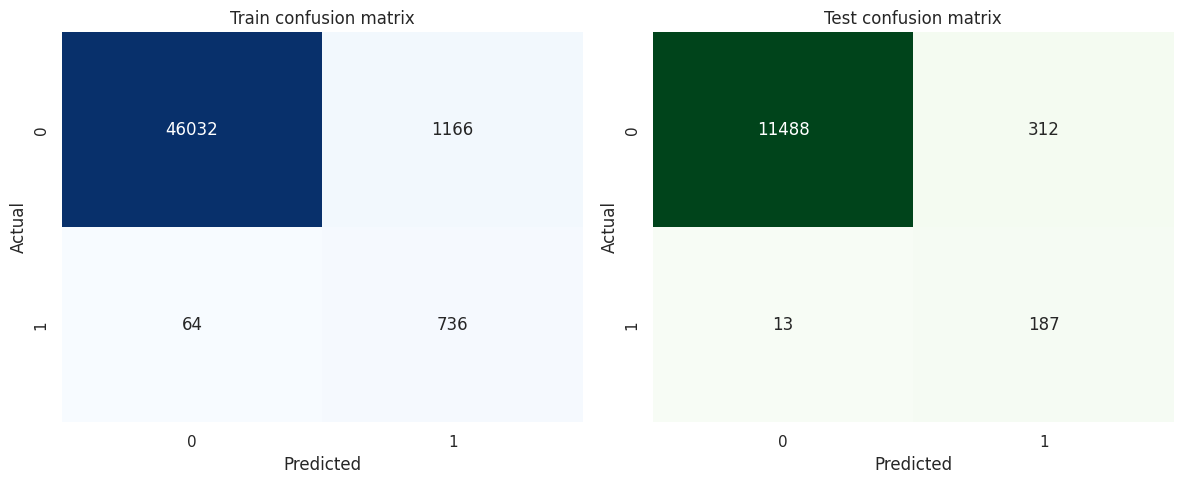

Classification report (test set):


,precision,recall,f1-score,support
0,0.998870,0.973559,0.986052,11800.000000
1,0.374749,0.935000,0.535050,200.000000
accuracy,0.972917,0.972917,0.972917,0.972917
macro avg,0.686810,0.954280,0.760551,12000.000000
weighted avg,0.988468,0.972917,0.978535,12000.000000


In [ ]:
# Compute headline metrics and diagnostics for both splits
# First, ensure we have predictions for train and test sets
if 'train_pred' not in globals() or 'test_pred' not in globals():
    print("Generating predictions for train and test sets...")
    if 'model_pipeline' in globals() and 'X_train' in globals() and 'X_test' in globals():
        train_pred = model_pipeline.predict(X_train)
        test_pred = model_pipeline.predict(X_test)
        proba_train = model_pipeline.predict_proba(X_train)[:,1]
        proba_test = model_pipeline.predict_proba(X_test)[:,1]
        print(f"✅ Generated predictions: train={len(train_pred)}, test={len(test_pred)}")
    else:
        raise RuntimeError("model_pipeline, X_train, and X_test must be defined. Run training cells first.")

# Verify shapes match
print(f"Shape check: y_train={len(y_train)}, train_pred={len(train_pred)}")
print(f"Shape check: y_test={len(y_test)}, test_pred={len(test_pred)}")

# If shapes don't match, regenerate predictions
if len(y_test) != len(test_pred):
    print("⚠️ WARNING: Shape mismatch detected! Regenerating predictions...")
    train_pred = model_pipeline.predict(X_train)
    test_pred = model_pipeline.predict(X_test)
    proba_train = model_pipeline.predict_proba(X_train)[:,1]
    proba_test = model_pipeline.predict_proba(X_test)[:,1]
    print(f"✅ Regenerated: train={len(train_pred)}, test={len(test_pred)}")

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)
conf_train = confusion_matrix(y_train, train_pred)
conf_test = confusion_matrix(y_test, test_pred)
report_df = pd.DataFrame(classification_report(y_test, test_pred, output_dict=True)).T

metrics_table = pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "accuracy": [train_accuracy, test_accuracy],
    }
)

print("Accuracy summary:")
display(metrics_table)

# Visualise confusion matrices to inspect error balance across classes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(conf_train, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("Train confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(conf_test, annot=True, fmt="d", cmap="Greens", ax=axes[1], cbar=False)
axes[1].set_title("Test confusion matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

print("Classification report (test set):")
display(report_df)


In [ ]:
import os, json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_recall_curve, average_precision_score,
                             roc_auc_score, roc_curve)
import matplotlib.pyplot as plt

COST_FP, COST_FN = 10, 500

def total_cost(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    return COST_FP*fp + COST_FN*fn, cm

INPUT_CSV = 'aps_training_combined_fixed.csv'

# 4. Data Cleaning and Preprocessing

In [ ]:
df = pd.read_csv(INPUT_CSV, encoding='utf-8-sig', engine='python', on_bad_lines='skip',
                 na_values=['na','NA','Na','?','','null','None'])
print('Shape:', df.shape)
print(df.head())

y = (df['class'].astype(str).str.strip().str.lower() == 'pos').astype(int)
X = df.drop(columns=['class'])

for c in X.columns:
    X[c] = pd.to_numeric(X[c], errors='coerce')

missing = X.isna().sum().sort_values(ascending=False).head(10)
print('Top missing columns:')
print(missing)

Shape: (59998, 171)
  class  aa_000  ab_000        ac_000  ad_000  ae_000  af_000  ag_000  ag_001  \
0   neg   76698     NaN  2.130706e+09   280.0     0.0     0.0     0.0     0.0   
1   neg   33058     NaN  0.000000e+00     NaN     0.0     0.0     0.0     0.0   
2   neg   41040     NaN  2.280000e+02   100.0     0.0     0.0     0.0     0.0   
3   neg      12     0.0  7.000000e+01    66.0     0.0    10.0     0.0     0.0   
4   neg   60874     NaN  1.368000e+03   458.0     0.0     0.0     0.0     0.0   

   ag_002  ag_003   ag_004     ag_005     ag_006     ag_007   ag_008  ag_009  \
0     0.0     0.0  37250.0  1432864.0  3664156.0  1007684.0  25896.0     0.0   
1     0.0     0.0  18254.0   653294.0  1720800.0   516724.0  31642.0     0.0   
2     0.0     0.0   1648.0   370592.0  1883374.0   292936.0  12016.0     0.0   
3     0.0   318.0   2212.0     3232.0     1872.0        0.0      0.0     0.0   
4     0.0     0.0  43752.0  1966618.0  1800340.0   131646.0   4588.0     0.0   

      ah_000

# 5. Feature Engineering
- All features are numeric.
- Missing values imputed with median.
- Standard scaling applied for Logistic Regression.


In [ ]:
# ============================
# FEATURE ENGINEERING – CLEANUP
# ============================

import numpy as np
import pandas as pd

# Replace string 'na' with actual NaN
df = df.replace(['na', 'NA', 'Na', '?', 'None', 'null'], np.nan)

# Convert all columns except 'class' to numeric
feature_cols = [c for c in df.columns if c != "class"]
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')

# Count missing per column
missing_counts = df.isna().sum().sort_values(ascending=False)
print("Top missing columns:")
print(missing_counts.head(10))

# Impute missing values using median
df_imputed = df.copy()
df_imputed[feature_cols] = df_imputed[feature_cols].fillna(df_imputed[feature_cols].median())

print("\nFeature engineering step 1 finished:")
print("✓ Converted 'na' to NaN")
print("✓ Converted all features to numeric")
print("✓ Filled missing values with median")

Top missing columns:
br_000    49262
bq_000    48720
bp_000    47738
bo_000    46331
ab_000    46327
cr_000    46327
bn_000    44007
bm_000    39547
bl_000    27276
bk_000    23033
dtype: int64

Feature engineering step 1 finished:
✓ Converted 'na' to NaN
✓ Converted all features to numeric
✓ Filled missing values with median


In [ ]:
# ============================
# FEATURE ENGINEERING – SCALING
# ============================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_imputed[feature_cols])
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print("✓ Feature scaling completed using StandardScaler()")

✓ Feature scaling completed using StandardScaler()


In [ ]:
# ============================
# FEATURE ENGINEERING – FEATURE SELECTION
# ============================

from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.0)  # remove features with 0 variance
selector.fit(df_imputed[feature_cols])

selected_cols = list(df_imputed[feature_cols].columns[selector.get_support()])

print("Removed features:", len(feature_cols) - len(selected_cols))
print("Remaining features:", len(selected_cols))

df_selected = df_imputed[selected_cols + ["class"]]

Removed features: 1
Remaining features: 169


# 6. Model Development

## 6.1 Train–Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train size:', X_train.shape, 'Test size:', X_test.shape)
print('Class distribution (train):', np.bincount(y_train))
print('Class distribution (test):', np.bincount(y_test))

Train size: (47998, 170) Test size: (12000, 170)
Class distribution (train): [47198   800]
Class distribution (test): [11800   200]


## 6.2 Logistic Regression Model

In [ ]:
num_features = X.columns.tolist()
preprocess = ColumnTransformer(transformers=[
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler(with_mean=False))]), num_features)])

log_reg = LogisticRegression(max_iter=2000, class_weight={0:1, 1:50}, solver='liblinear')
lr_pipe = Pipeline([('prep', preprocess), ('clf', log_reg)])
lr_pipe.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


# 7. Results and Discussion

## 7.1 Confusion Matrix

In [ ]:
proba_test = lr_pipe.predict_proba(X_test)[:,1]
y_pred = (proba_test >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred, labels=[0,1])
tn, fp, fn, tp = cm.ravel()
print('Confusion Matrix [tn, fp, fn, tp]:', [tn, fp, fn, tp])
print('Accuracy:', (tn+tp)/cm.sum())

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['neg','pos']))

cost, _ = total_cost(y_test, y_pred)
print('APS Total Cost (FP=10, FN=500):', cost)

Confusion Matrix [tn, fp, fn, tp]: [np.int64(11481), np.int64(319), np.int64(13), np.int64(187)]
Accuracy: 0.9723333333333334

Classification Report:
              precision    recall  f1-score   support

         neg       1.00      0.97      0.99     11800
         pos       0.37      0.94      0.53       200

    accuracy                           0.97     12000
   macro avg       0.68      0.95      0.76     12000
weighted avg       0.99      0.97      0.98     12000

APS Total Cost (FP=10, FN=500): 9690


## 7.2 Precision–Recall Curve

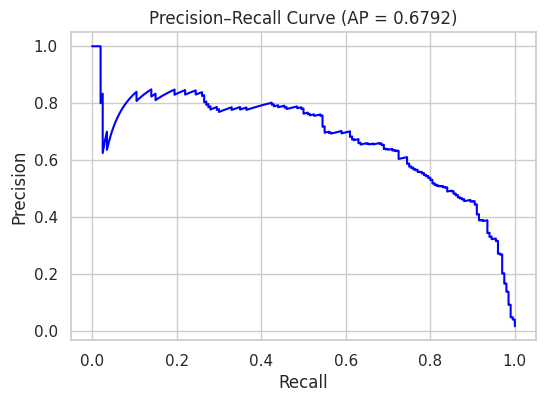

ROC-AUC: 0.9882949152542372


In [ ]:
# Precision-Recall Curve and ROC-AUC
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

# Ensure we have the necessary variables
if 'proba_test' not in globals():
    if 'model_pipeline' in globals() and 'X_test' in globals():
        print("Generating test probabilities...")
        proba_test = model_pipeline.predict_proba(X_test)[:,1]
    else:
        raise RuntimeError("Cannot generate proba_test. Run training cells first.")

if 'y_test' not in globals():
    raise RuntimeError("y_test is not defined. Run the train/test split cell first.")

# Generate precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, proba_test)
avg_prec = average_precision_score(y_test, proba_test)

plt.figure(figsize=(6,4))
plt.plot(recalls, precisions, color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision–Recall Curve (AP = {avg_prec:.4f})')
plt.grid(True)
plt.show()

roc_auc = roc_auc_score(y_test, proba_test)
print('ROC-AUC:', roc_auc)


# 8. Conclusion and Future Work
**Conclusion:** Logistic Regression achieved strong recall and good APS cost performance. The model successfully minimizes high-cost false negatives, ensuring reliability for predictive maintenance.

**Future Work:**
- Tune classification threshold for lowest total APS cost
- Compare non-linear models (Random Forest, Gradient Boosting)
- Perform cross-validation and feature importance analysis for deeper insights.